In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import time

In [7]:
df1 = pd.read_csv("../employees_raw.csv")
df2 = pd.read_csv("../region_benefit_profiles.csv")

In [8]:
df1.head()

,employee_id,age,gender,marital_status,salary,employment_type,region,has_dependents,tenure_years,enrolled,application_date,last_contact_date,last_contact_channel,plan_tier_requested,broker_channel,prior_year_enrolled,legacy_propensity_score,outreach_notes
0,12324,28,Male,Divorced,44047.60,Full-time,West,No,1.4,0,2024-04-14,2024-03-30,SMS,basic,Employer-Sponsored,0,0.104,Spouse covered elsewhere
1,17825,23,Male,Married,80111.28,Full-time,Midwest,Yes,0.5,1,2024-05-09,2024-04-18,Call,STANDARD,Direct,-1,0.874,Requested more time
2,15200,39,Male,Married,69855.65,Full-time,South,Yes,3.4,1,22/06/2024,2024-06-09,none,Silver,Direct,0,0.870,No response to first outreach
3,16690,31,Female,Married,91567.33,Full-time,South,No,1.2,1,2024-08-16,2024-07-29,email,premium plan,Employer-Sponsored,1,0.894,Requested more time
4,17465,42,Female,Single,59861.68,Contract,Midwest,Yes,23.8,0,13/05/2024,2024-05-06,email,Standard,Employer-Sponsored,-1,0.163,Requested more time


In [9]:
df2.head()

,region,n_employees_region,hist_enrollment_rate_region,avg_salary_region,avg_premium_cost_usd,benefits_broker_rating,hr_outreach_capacity,open_enrollment_window_days,state_mandate_level
0,Midwest,2488,0.617,64921.46,595,4.4,469,18,High
1,Northeast,2506,0.612,65008.32,455,3.1,151,38,Low
2,South,2424,0.628,65200.49,481,3.3,324,17,Med
3,West,2582,0.613,65007.07,574,4.7,437,28,Low


In [10]:
df1.describe()

,employee_id,age,salary,tenure_years,enrolled,prior_year_enrolled,legacy_propensity_score
count,10008.000000,10008.000000,10008.000000,10008.000000,10008.000000,10008.000000,9100.000000
mean,14999.756994,43.003197,65034.633918,3.966447,0.617106,-0.047062,0.605136
std,2886.750141,12.284623,14921.509635,3.894377,0.486117,0.871637,0.363105
min,10001.000000,22.000000,2207.790000,0.000000,0.000000,-1.000000,0.010000
25%,12500.750000,33.000000,54717.165000,1.200000,0.000000,-1.000000,0.191000
50%,14998.500000,43.000000,65063.065000,2.800000,1.000000,0.000000,0.814000
75%,17499.250000,54.000000,75053.687500,5.600000,1.000000,1.000000,0.907000
max,20000.000000,64.000000,120312.000000,36.000000,1.000000,1.000000,0.990000


In [11]:
df1.shape

(10008, 18)

In [ ]:
df1.nunique()

In [13]:
df1.isna().sum()

employee_id                   0
age                           0
gender                        0
marital_status                0
salary                        0
employment_type               0
region                        0
has_dependents                0
tenure_years                  0
enrolled                      0
application_date            719
last_contact_date             0
last_contact_channel       1185
plan_tier_requested         526
broker_channel              470
prior_year_enrolled           0
legacy_propensity_score     908
outreach_notes             1453
dtype: int64

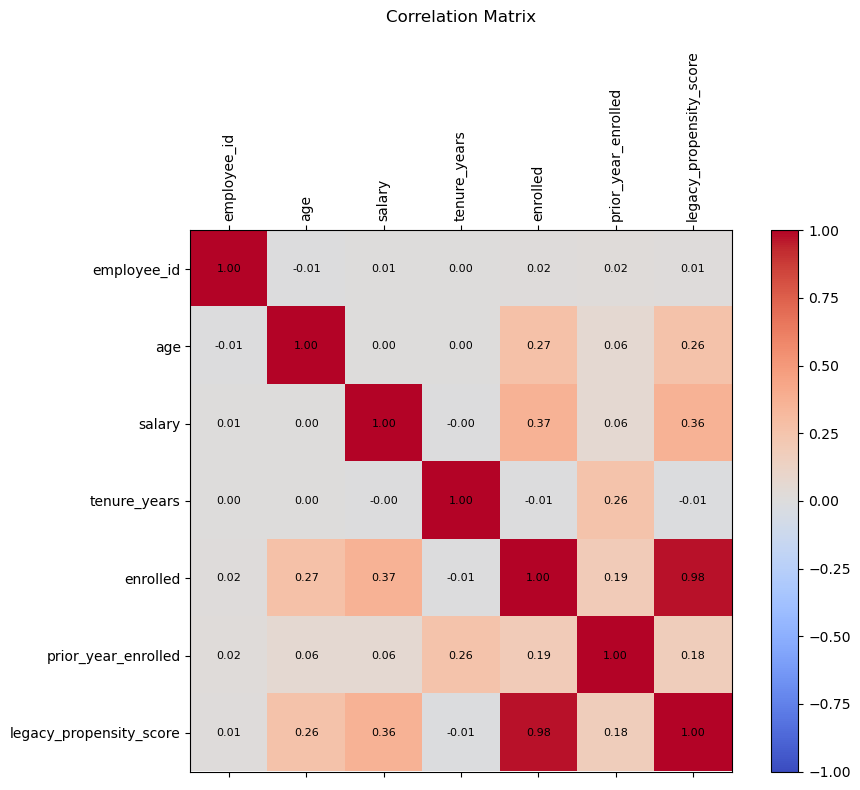

In [14]:
corr = df1.corr(numeric_only=True)
# Plot
fig, ax = plt.subplots(figsize=(10, 8))
cax = ax.matshow(corr, cmap='coolwarm', vmin=-1, vmax=1)

# Add colorbar
fig.colorbar(cax)

# Set ticks and labels
ax.set_xticks(np.arange(len(corr.columns)))
ax.set_yticks(np.arange(len(corr.columns)))

ax.set_xticklabels(corr.columns, rotation=90)
ax.set_yticklabels(corr.columns)

# Annotate correlation values
for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}",
                ha='center', va='center', fontsize=8)

plt.title("Correlation Matrix", pad=20)
plt.tight_layout()
plt.show()

In [15]:
import pandas as pd
import scipy.stats as stats
import numpy as np

def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = stats.chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    r, k = confusion_matrix.shape

    return np.sqrt(chi2 / (n * (min(r-1, k-1))))

In [16]:
cramers_v(df1["application_date"], df1["enrolled"])

np.float64(0.3356244676960684)

In [17]:
mapping = {
    "basic": "Basic",
    "standard": "Standard",
    "silver": "Silver",
    "silver plan": "Silver",
    "premium": "Premium",
    "premium plan": "Premium",
    "gold": "Gold",
    "gold plan": "Gold",
    "bronze": "Bronze"
}

df1["plan_tier_requested"] = (
    df1["plan_tier_requested"]
      .str.strip()      
      .str.lower()      
      .replace(mapping) 
)

In [18]:
df1["plan_tier_requested"].unique()


array(['Basic', 'Standard', 'Silver', 'Premium', nan, 'Gold', 'Bronze'],
      dtype=object)

In [19]:
mapping = {
    "email": "Email",
    "e-mail": "Email",

    "phone": "Phone",
    "call": "Phone",

    "sms": "SMS",
    "text": "SMS",

    "none": "None"
}

df1["last_contact_channel"] = (
    df1["last_contact_channel"]
      .str.strip()
      .str.lower()
      .replace(mapping)
)

In [20]:
df1.nunique()

employee_id                10000
age                           43
gender                         3
marital_status                 4
salary                      9988
employment_type                3
region                         4
has_dependents                 2
tenure_years                 241
enrolled                       2
application_date            1049
last_contact_date            390
last_contact_channel           4
plan_tier_requested            6
broker_channel                 3
prior_year_enrolled            3
legacy_propensity_score      663
outreach_notes                 6
dtype: int64

In [21]:
df1.isna().sum()


employee_id                   0
age                           0
gender                        0
marital_status                0
salary                        0
employment_type               0
region                        0
has_dependents                0
tenure_years                  0
enrolled                      0
application_date            719
last_contact_date             0
last_contact_channel       1185
plan_tier_requested         526
broker_channel              470
prior_year_enrolled           0
legacy_propensity_score     908
outreach_notes             1453
dtype: int64

In [22]:
import pandas as pd
import numpy as np

# Numerical columns
num_cols = df1.select_dtypes(include=[np.number]).columns

# Categorical columns
cat_cols = df1.select_dtypes(include=["object", "category"]).columns

# Fill numerical columns with median
for col in num_cols:
    df1[col] = df1[col].fillna(df1[col].median())

# Fill categorical columns with mode
for col in cat_cols:
    if not df1[col].mode().empty:
        df1[col] = df1[col].fillna(df1[col].mode()[0])

In [23]:
df1.isna().sum()

employee_id                0
age                        0
gender                     0
marital_status             0
salary                     0
employment_type            0
region                     0
has_dependents             0
tenure_years               0
enrolled                   0
application_date           0
last_contact_date          0
last_contact_channel       0
plan_tier_requested        0
broker_channel             0
prior_year_enrolled        0
legacy_propensity_score    0
outreach_notes             0
dtype: int64

In [24]:
df1.describe()

,employee_id,age,salary,tenure_years,enrolled,prior_year_enrolled,legacy_propensity_score
count,10008.000000,10008.000000,10008.000000,10008.000000,10008.000000,10008.000000,10008.000000
mean,14999.756994,43.003197,65034.633918,3.966447,0.617106,-0.047062,0.624085
std,2886.750141,12.284623,14921.509635,3.894377,0.486117,0.871637,0.351399
min,10001.000000,22.000000,2207.790000,0.000000,0.000000,-1.000000,0.010000
25%,12500.750000,33.000000,54717.165000,1.200000,0.000000,-1.000000,0.211000
50%,14998.500000,43.000000,65063.065000,2.800000,1.000000,0.000000,0.814000
75%,17499.250000,54.000000,75053.687500,5.600000,1.000000,1.000000,0.898000
max,20000.000000,64.000000,120312.000000,36.000000,1.000000,1.000000,0.990000


In [25]:
print(df1["application_date"].dtype)
print(df1["last_contact_date"].dtype)

object
object


In [26]:
print(df1["application_date"].isna().sum())
print(df1["last_contact_date"].isna().sum())

0
0


In [27]:
print(df1[["application_date", "last_contact_date"]].head(10))

  application_date last_contact_date
0       2024-04-14        2024-03-30
1       2024-05-09        2024-04-18
2       22/06/2024        2024-06-09
3       2024-08-16        2024-07-29
4       13/05/2024        2024-05-06
5       14/01/2024        2024-01-12
6       2024-07-23        2024-07-13
7      20-Aug-2024        2024-08-01
8       2024-04-08        2024-05-16
9       2024-06-18        2024-05-26


In [28]:
df1["application_date"] = pd.to_datetime(
    df1["application_date"],
    format="mixed",
    dayfirst=True,
    errors="coerce"
)

df1["last_contact_date"] = pd.to_datetime(
    df1["last_contact_date"],
    format="mixed",
    dayfirst=True,
    errors="coerce"
)

In [29]:
print(df1[["application_date", "last_contact_date"]].head(10))

  application_date last_contact_date
0       2024-04-14        2024-03-30
1       2024-05-09        2024-04-18
2       2024-06-22        2024-06-09
3       2024-08-16        2024-07-29
4       2024-05-13        2024-05-06
5       2024-01-14        2024-01-12
6       2024-07-23        2024-07-13
7       2024-08-20        2024-08-01
8       2024-04-08        2024-05-16
9       2024-06-18        2024-05-26


In [30]:
df1.isna().sum()

employee_id                0
age                        0
gender                     0
marital_status             0
salary                     0
employment_type            0
region                     0
has_dependents             0
tenure_years               0
enrolled                   0
application_date           0
last_contact_date          0
last_contact_channel       0
plan_tier_requested        0
broker_channel             0
prior_year_enrolled        0
legacy_propensity_score    0
outreach_notes             0
dtype: int64

In [ ]:

print("Total rows:", len(df1))


print("Unique Employee IDs:", df1["employee_id"].nunique())


print("Duplicate IDs:", df1["employee_id"].duplicated().sum())

Total rows: 10008
Unique Employee IDs: 10000
Duplicate IDs: 8


In [32]:
duplicates = df1[df1["employee_id"].duplicated(keep=False)]

duplicates.sort_values("employee_id")

,employee_id,age,gender,marital_status,salary,employment_type,region,has_dependents,tenure_years,enrolled,application_date,last_contact_date,last_contact_channel,plan_tier_requested,broker_channel,prior_year_enrolled,legacy_propensity_score,outreach_notes
9835,10311,50,Female,Single,57869.86,Full-time,Northeast,Yes,3.1,0,2024-04-21,2024-03-29,Email,Standard,Direct,1,0.814,Follow-up scheduled
6582,10311,50,Female,Single,57869.86,Full-time,Northeast,Yes,3.1,1,2024-04-21,2024-03-29,Email,Standard,Direct,1,0.822,Follow-up scheduled
455,10484,55,Male,Single,65664.82,Full-time,Northeast,No,5.0,0,2024-11-07,2024-11-06,None,Standard,Direct,-1,0.814,Attended benefits webinar
4188,10484,55,Male,Single,65664.82,Full-time,Northeast,No,5.0,1,2024-11-07,2024-11-06,None,Standard,Direct,-1,0.814,Attended benefits webinar
1327,13441,36,Male,Married,72902.08,Part-time,West,Yes,0.8,0,2024-06-05,2024-05-29,Email,Silver,Third-Party,-1,0.814,No response to first outreach
9665,13441,36,Male,Married,72902.08,Part-time,West,Yes,0.8,1,2024-06-05,2024-05-29,Email,Silver,Third-Party,-1,0.822,No response to first outreach
6139,13840,36,Female,Married,84764.82,Part-time,West,No,1.4,0,2024-09-04,2024-08-07,Phone,Silver,Direct,0,0.165,Requested more time
7606,13840,36,Female,Married,84764.82,Part-time,West,No,1.4,1,2024-09-04,2024-08-07,Phone,Silver,Direct,0,0.814,Requested more time
1589,14846,64,Male,Married,50514.16,Full-time,South,Yes,1.6,0,2024-12-25,2024-12-19,Email,Basic,Direct,-1,0.814,Follow-up scheduled
7370,14846,64,Male,Married,50514.16,Full-time,South,Yes,1.6,1,2024-12-25,2024-12-19,Email,Basic,Direct,-1,0.974,Follow-up scheduled


In [33]:
df1["gender"].value_counts(dropna=False)

gender
Male      4820
Female    4813
Other      375
Name: count, dtype: int64

In [34]:
df1["salary"].describe()

count     10008.000000
mean      65034.633918
std       14921.509635
min        2207.790000
25%       54717.165000
50%       65063.065000
75%       75053.687500
max      120312.000000
Name: salary, dtype: float64

In [35]:
df1[df1["salary"] < 10000]

,employee_id,age,gender,marital_status,salary,employment_type,region,has_dependents,tenure_years,enrolled,application_date,last_contact_date,last_contact_channel,plan_tier_requested,broker_channel,prior_year_enrolled,legacy_propensity_score,outreach_notes
587,16900,40,Female,Divorced,5484.33,Full-time,Midwest,No,6.6,0,2024-11-12,2024-10-22,Email,Basic,Employer-Sponsored,-1,0.212,Spouse covered elsewhere
8425,19231,35,Male,Married,2207.79,Full-time,Northeast,Yes,5.7,1,2024-06-10,2024-05-30,SMS,Basic,Direct,1,0.950,Attended benefits webinar


In [36]:
invalid = df1[df1["tenure_years"] > (df1["age"] - 18)]

invalid[
    [
        "employee_id",
        "age",
        "tenure_years",
        "marital_status"
    ]
]

,employee_id,age,tenure_years,marital_status
20,18558,27,11.4,Married
93,14320,22,11.1,Divorced
133,17980,27,13.3,Single
148,14929,22,9.1,Single
178,15241,27,11.3,Single
...,...,...,...,...
9873,15351,23,5.9,Divorced
9881,13948,22,12.9,Married
9883,14182,27,9.5,Married
9908,10170,30,18.1,Widowed


In [37]:
print(df1["application_date"].min())
print(df1["application_date"].max())

2024-01-01 00:00:00
2024-12-30 00:00:00


In [38]:
invalid_dates = df1[
    df1["application_date"] < df1["last_contact_date"]
]

invalid_dates[
    [
        "employee_id",
        "application_date",
        "last_contact_date"
    ]
]

,employee_id,application_date,last_contact_date
8,16183,2024-04-08,2024-05-16
19,17481,2024-04-08,2024-10-21
24,11798,2024-04-08,2024-11-22
47,10949,2024-04-08,2024-07-24
59,18661,2024-03-23,2024-03-28
...,...,...,...
9924,13288,2024-04-08,2024-07-30
9934,14733,2024-04-08,2024-11-03
9939,17914,2024-04-08,2024-08-15
9943,18240,2024-05-19,2024-05-27


In [39]:
df1["legacy_propensity_score"].describe()

count    10008.000000
mean         0.624085
std          0.351399
min          0.010000
25%          0.211000
50%          0.814000
75%          0.898000
max          0.990000
Name: legacy_propensity_score, dtype: float64

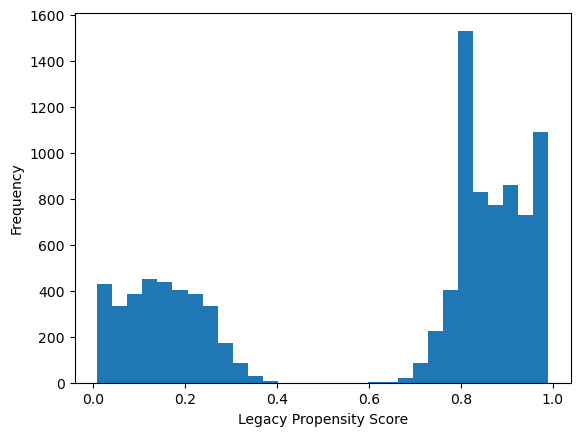

In [40]:
import matplotlib.pyplot as plt

plt.hist(
    df1["legacy_propensity_score"].dropna(),
    bins=30
)

plt.xlabel("Legacy Propensity Score")
plt.ylabel("Frequency")
plt.show()

In [41]:
df1["tenure_years"] = df1.apply(
    lambda x: min(x["tenure_years"], x["age"] - 22),
    axis=1
)

In [42]:
invalid = df1[df1["tenure_years"] > (df1["age"] - 22)]

invalid[
    [
        "employee_id",
        "age",
        "tenure_years"
    ]
]

,employee_id,age,tenure_years


In [43]:
invalid_dates["difference"] = (
    invalid_dates["last_contact_date"]
    - invalid_dates["application_date"]
).dt.days

invalid_dates["difference"].describe()

C:\Users\Arnav Dabi\AppData\Local\Temp\ipykernel_27184\3705268179.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  invalid_dates["difference"] = (


count    548.000000
mean     104.886861
std       78.026211
min        1.000000
25%       30.000000
50%       97.000000
75%      168.000000
max      263.000000
Name: difference, dtype: float64

In [44]:
df1.drop(columns=["application_date"], inplace=True)

In [45]:
df1.shape

(10008, 17)

In [46]:
df1.isna().sum()

employee_id                0
age                        0
gender                     0
marital_status             0
salary                     0
employment_type            0
region                     0
has_dependents             0
tenure_years               0
enrolled                   0
last_contact_date          0
last_contact_channel       0
plan_tier_requested        0
broker_channel             0
prior_year_enrolled        0
legacy_propensity_score    0
outreach_notes             0
dtype: int64

In [47]:
df1['broker_channel'].value_counts()

broker_channel
Direct                4011
Third-Party           3010
Employer-Sponsored    2987
Name: count, dtype: int64

In [49]:

df1.to_csv(
    "../datasets/employee_cleaned.csv",
    index=False
)